# Percentile Method for Outlier Detection

This note explains using percentiles to detect and handle outliers, and includes runnable Python examples for detection, trimming (removal), and capping (winsorizing). Paste this whole markdown into a Jupyter Notebook markdown cell.

---

## 1. What is the percentile method?

- Percentiles (or quantiles) split the data distribution into intervals.  
  - The p-th percentile is the value below which p% of observations fall.
- The percentile method marks as outliers values that fall below a chosen lower percentile (e.g., 1st) or above a chosen upper percentile (e.g., 99th).
- It's a non-parametric, robust approach that does not assume normality.

---

## 2. Common percentile thresholds

- Symmetric tails:
  - 1st and 99th percentiles (1% / 99%) — common when you want to remove/limit the most extreme 1% on each tail.
  - 0.5% and 99.5% — more aggressive trimming of extremes.
  - 2.5% and 97.5% — corresponds to central 95% range.
  - 5% and 95% — milder trimming/capping.
- One-sided approaches:
  - Use only an upper percentile (e.g., 99th) for right-skewed variables (like income).
  - Use only a lower percentile for left-skewed cases.
- Choose percentiles based on domain knowledge, sample size, and tolerance for removing/altering observations.

---

## 3. How to use the percentile method (workflow)

1. Choose percentile cutoffs: lower_p and upper_p (e.g., 0.01 and 0.99 for 1%/99%).  
2. Compute cutoff values: lower_value = quantile(lower_p), upper_value = quantile(upper_p).  
3. Detect outliers:
   - lower outliers: x < lower_value
   - upper outliers: x > upper_value
4. Decide action:
   - Inspect flagged observations.
   - Trim (remove) rows with outliers.
   - Cap (winsorize) values outside cutoffs to the cutoff values.
   - Keep them and use robust modeling if they are real and important.

---

## 4. Trimming vs Capping (Winsorizing) with percentiles

- Trimming (removal)
  - Remove observations outside chosen percentiles.
  - Pros: simple, removes extreme influence.
  - Cons: reduces sample size; can bias results if extremes are valid.
  - Use when extremes are measurement errors or irrelevant.
- Capping / Winsorizing
  - Replace values below lower_value with lower_value, and above upper_value with upper_value.
  - Pros: retains full sample, reduces influence of extremes.
  - Cons: introduces bias near the tails; alters distribution.
  - Use when you want to limit influence but preserve rows.

---

## 5. Advantages and limitations

- Advantages:
  - Non-parametric and robust (uses percentiles).
  - Easy to implement and interpret.
  - Flexible: symmetric or one-sided.
- Limitations:
  - Arbitrary percentile choices — requires domain judgment.
  - Univariate: applies per variable independently; doesn't detect multivariate outliers.
  - For small samples, percentile estimates can be unstable.
  - Capping changes the tail behavior and can bias variance estimates.

---

## 6. Visualization & investigation

- Visual tools:
  - Histogram / density plot — to see tails
  - Boxplot — for median and IQR context
  - ECDF (empirical CDF) — to see percentile positions
  - Scatter plots — to inspect flagged rows
- Always inspect flagged points before deciding to remove or alter them.

---

In [42]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [43]:
df = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Machine Learning\CSV\weight-height.csv")

In [44]:
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


In [46]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


<Axes: xlabel='Weight', ylabel='Count'>

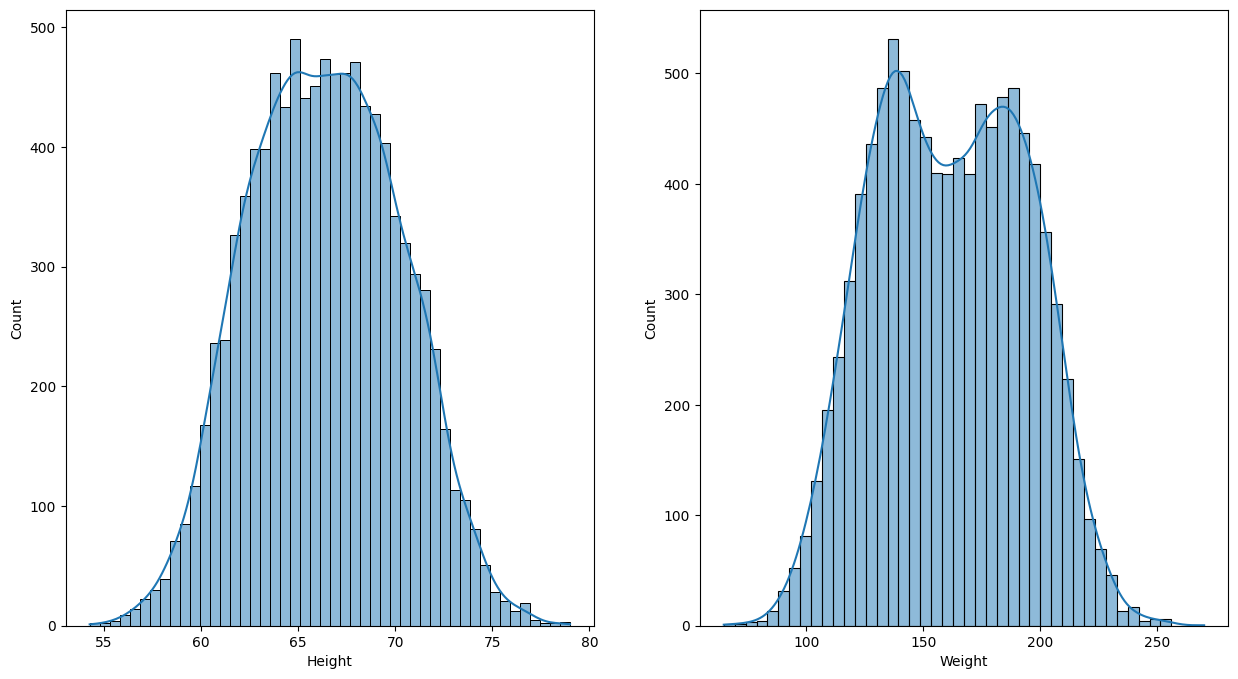

In [47]:
plt.figure(figsize=(15 , 8))
plt.subplot(1 , 2 , 1)
sns.histplot(data=df , x = df['Height'] , kde=True)
plt.subplot(1 , 2 , 2)
sns.histplot(data=df , x = df['Weight'] , kde=True)


In [48]:
df['Height'].skew() , df['Weight'].skew()

(np.float64(0.04936908937689042), np.float64(0.03295450444592442))

<Axes: ylabel='Height'>

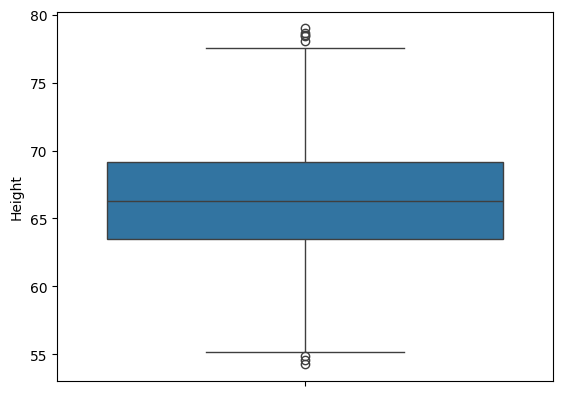

In [49]:
sns.boxplot(df['Height'])

In [50]:
upper_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01)
upper_limit , lower_limit

(np.float64(74.7857900583366), np.float64(58.13441158671655))

Keep note that when we deciding percentile we must adjust same limit upper and above to make 100 percentile . Eg: if i give 99 percentile upper limit then it must be 1 percentile lower limit . If I give 95 then I give lower limit 5 percentile .

In [51]:
df[(df['Height'] >= 74.78) | (df['Height'] <= 58.13)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [52]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


<Axes: ylabel='Density'>

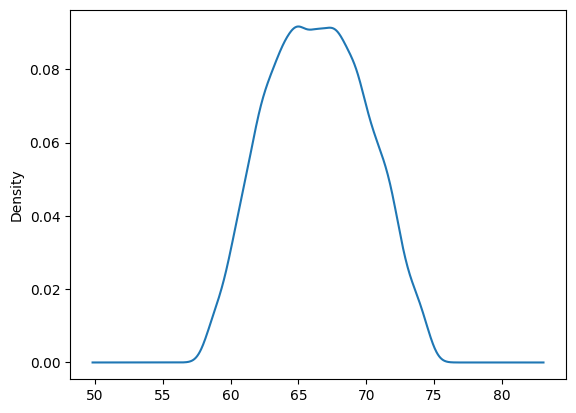

In [53]:
new_df['Height'].plot(kind='kde')

<Axes: ylabel='Height'>

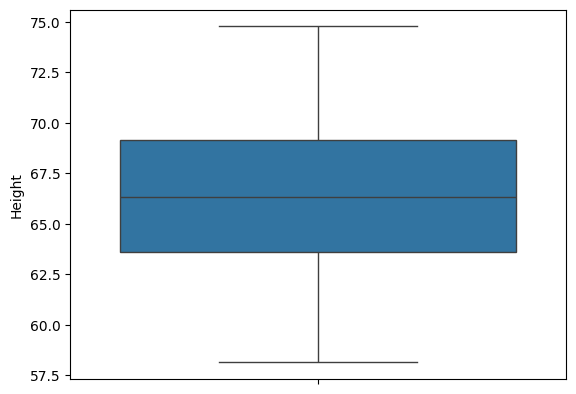

In [54]:
sns.boxplot(new_df['Height'])

In [55]:
# Capping(Winsorization)
new_df_cap = df.copy()
new_df_cap['Height'] = np.where(new_df_cap['Height']>upper_limit , upper_limit , np.where(new_df_cap['Height']<lower_limit , lower_limit , new_df_cap['Height']))

In [56]:
new_df_cap

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [57]:
new_df_cap.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.366281,161.440357
std,3.795717,32.108439
min,58.134412,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,74.785790,269.989699


<Axes: xlabel='Height', ylabel='Count'>

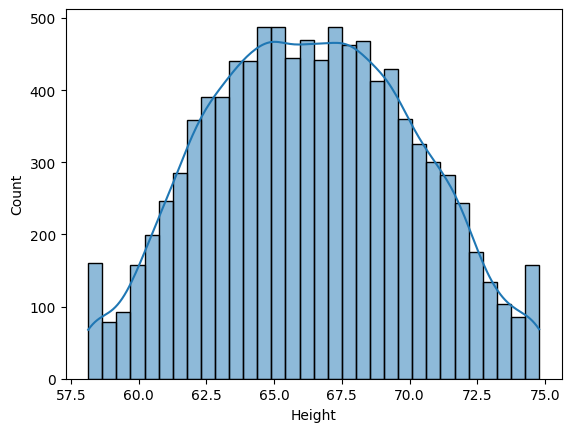

In [59]:
sns.histplot(data=new_df_cap , x = new_df_cap['Height'] , kde=True)

<Axes: ylabel='Height'>

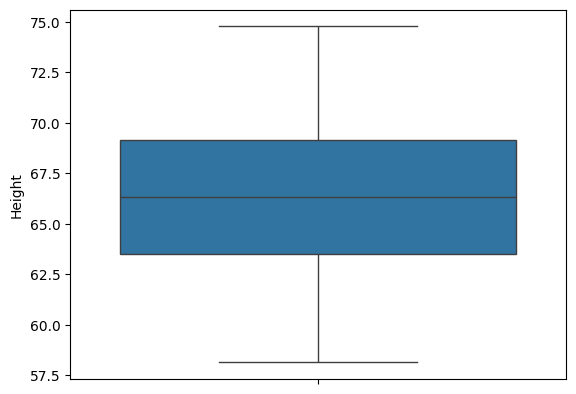

In [60]:
sns.boxplot(new_df_cap['Height'])